# M2-B1 — Audit Banque Eckmühl + industrialisation pipe

> **Mission** : auditer le dataset German Credit fourni par Eckmühl, identifier
> les risques qualité et éthiques, construire un Pipeline scikit-learn
> réutilisable, persister en Parquet, documenter dans une datasheet.

Auteur·rice : `JulienD` — Date : `16/06/2026`
/
/*Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser la cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "german_credit_raw.csv"
CLEAN_PATH = DATA_DIR / "german_credit_clean.parquet"

sns.set_theme(style="whitegrid")

## 1. Découverte du dataset (~30 min)

Chargement, types, premier aperçu. Repérage de la cible et des variables
sensibles évidentes (`age`, `personal_status_sex`, `foreign_worker`).

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
df = pd.read_csv(RAW_PATH, sep=";")

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   checking_account_status      1000 non-null   object
 1   duration_months              1000 non-null   int64 
 2   credit_history               1000 non-null   object
 3   purpose                      1000 non-null   object
 4   credit_amount                1000 non-null   int64 
 5   savings_account              1000 non-null   object
 6   employment_since             1000 non-null   object
 7   installment_rate_pct_income  1000 non-null   int64 
 8   personal_status_sex          1000 non-null   object
 9   other_debtors                1000 non-null   object
 10  residence_since_years        1000 non-null   int64 
 11  property                     1000 non-null   object
 12  age                          1000 non-null   int64 
 13  other_installment_plans      1000 

None

In [99]:
info_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "null_count": df.isna().sum().values,
    "null_percent": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique().values
})

display(info_df)

,column,dtype,non_null_count,null_count,null_percent,unique_values
0,checking_account_status,object,1000,0,0.000,4
1,duration_months,int64,1000,0,0.000,33
2,credit_history,object,1000,0,0.000,5
3,purpose,object,1000,0,0.000,10
4,credit_amount,int64,1000,0,0.000,921
5,savings_account,object,1000,0,0.000,5
6,employment_since,object,1000,0,0.000,5
7,installment_rate_pct_income,int64,1000,0,0.000,4
8,personal_status_sex,object,1000,0,0.000,4
9,other_debtors,object,1000,0,0.000,3


In [100]:
display(df.head())

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors,residence_since_years,property,age,other_installment_plans,housing,n_existing_credits,job,n_people_liable,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical account / other credits existing,radio/TV,1169,unknown / no savings,>= 7 years,4,male single,none,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered",yes,good_credit
1,0 to 200 DM,48,existing credits paid back duly,radio/TV,5951,< 100 DM,1-4 years,2,female divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee / official,1,none,yes,bad_credit
2,no checking account,12,critical account / other credits existing,education,2096,< 100 DM,4-7 years,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good_credit
3,< 0 DM,42,existing credits paid back duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male single,guarantor,4,savings agreement / life insurance,45,none,for free,1,skilled employee / official,2,none,yes,good_credit
4,< 0 DM,24,delay in paying off in past,car (new),4870,< 100 DM,1-4 years,3,male single,none,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,bad_credit


In [26]:

display(df.describe(include="all"))

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors,residence_since_years,property,age,other_installment_plans,housing,n_existing_credits,job,n_people_liable,telephone,foreign_worker,credit_risk
count,1000,1000.000,1000,1000,1000.000,1000,1000,1000.000,1000,1000,1000.000,1000,1000.000,1000,1000,1000.000,1000,1000.000,1000,1000,1000
unique,4,NaN,5,10,NaN,5,5,NaN,4,3,NaN,4,NaN,3,3,NaN,4,NaN,2,2,2
top,no checking account,NaN,existing credits paid back duly,radio/TV,NaN,< 100 DM,1-4 years,NaN,male single,none,NaN,car or other,NaN,none,own,NaN,skilled employee / official,NaN,none,yes,good_credit
freq,394,NaN,530,280,NaN,603,339,NaN,548,907,NaN,332,NaN,814,713,NaN,630,NaN,596,963,700
mean,NaN,20.903,NaN,NaN,3271.258,NaN,NaN,2.973,NaN,NaN,2.845,NaN,35.546,NaN,NaN,1.407,NaN,1.155,NaN,NaN,NaN
std,NaN,12.059,NaN,NaN,2822.737,NaN,NaN,1.119,NaN,NaN,1.104,NaN,11.375,NaN,NaN,0.578,NaN,0.362,NaN,NaN,NaN
min,NaN,4.000,NaN,NaN,250.000,NaN,NaN,1.000,NaN,NaN,1.000,NaN,19.000,NaN,NaN,1.000,NaN,1.000,NaN,NaN,NaN
25%,NaN,12.000,NaN,NaN,1365.500,NaN,NaN,2.000,NaN,NaN,2.000,NaN,27.000,NaN,NaN,1.000,NaN,1.000,NaN,NaN,NaN
50%,NaN,18.000,NaN,NaN,2319.500,NaN,NaN,3.000,NaN,NaN,3.000,NaN,33.000,NaN,NaN,1.000,NaN,1.000,NaN,NaN,NaN
75%,NaN,24.000,NaN,NaN,3972.250,NaN,NaN,4.000,NaN,NaN,4.000,NaN,42.000,NaN,NaN,2.000,NaN,1.000,NaN,NaN,NaN


## 2. Audit qualité (~1 h)

Manquants, outliers, types, cohérence des modalités. **Au moins 4
visualisations** : distribution cible, distribution `age`, distribution
`credit_amount`, crosstab sensible (ex. `credit_risk` × `personal_status_sex`).

> *Quels problèmes de qualité ai-je identifiés ?* — court paragraphe à
> rédiger ici.

In [101]:
# TODO — manquants par colonne
df.isna().sum().sort_values(ascending=False)

checking_account_status        0
property                       0
foreign_worker                 0
telephone                      0
n_people_liable                0
job                            0
n_existing_credits             0
housing                        0
other_installment_plans        0
age                            0
residence_since_years          0
duration_months                0
other_debtors                  0
personal_status_sex            0
installment_rate_pct_income    0
employment_since               0
savings_account                0
credit_amount                  0
purpose                        0
credit_history                 0
credit_risk                    0
dtype: int64

In [102]:

# Outliers
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    outlier_summary.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "n_outliers": n_outliers,
        "outlier_percent": round(n_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.sort_values("n_outliers", ascending=False))


,column,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,outlier_percent
6,n_people_liable,1.000,1.000,0.000,1.000,1.000,155,15.500
1,credit_amount,1365.500,3972.250,2606.750,-2544.625,7882.375,72,7.200
0,duration_months,12.000,24.000,12.000,-6.000,42.000,70,7.000
4,age,27.000,42.000,15.000,4.500,64.500,23,2.300
5,n_existing_credits,1.000,2.000,1.000,-0.500,3.500,6,0.600
2,installment_rate_pct_income,2.000,4.000,2.000,-1.000,7.000,0,0.000
3,residence_since_years,2.000,4.000,2.000,-1.000,7.000,0,0.000


In [103]:

categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False))



--- checking_account_status ---


checking_account_status
no checking account               394
< 0 DM                            274
0 to 200 DM                       269
>= 200 DM / salary assignments     63
Name: count, dtype: int64


--- credit_history ---


credit_history
existing credits paid back duly              530
critical account / other credits existing    293
delay in paying off in past                   88
all credits at this bank paid                 49
no credits taken / all paid                   40
Name: count, dtype: int64


--- purpose ---


...

telephone
none               596
yes, registered    404
Name: count, dtype: int64


--- foreign_worker ---


foreign_worker
yes    963
no      37
Name: count, dtype: int64


--- credit_risk ---


credit_risk
good_credit    700
bad_credit     300
Name: count, dtype: int64

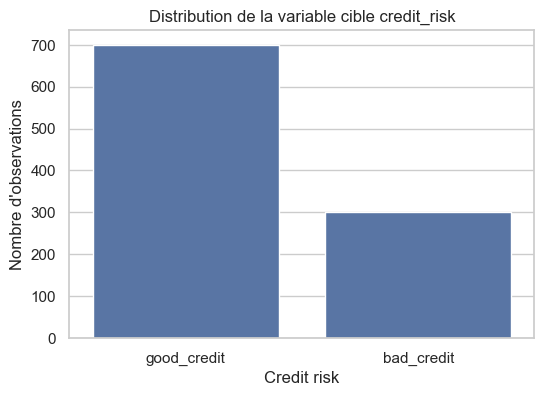

In [35]:
# TODO — visualisation 1 : distribution de la cible
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="credit_risk")
plt.title("Distribution de la variable cible credit_risk")
plt.xlabel("Credit risk")
plt.ylabel("Nombre d'observations")
plt.show()

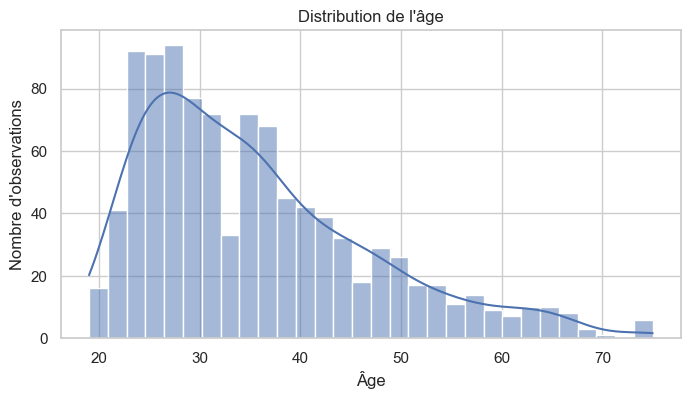

In [37]:
# Distribution de l'âge
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="age", bins=30, kde=True)
plt.title("Distribution de l'âge")
plt.xlabel("Âge")
plt.ylabel("Nombre d'observations")
plt.show()

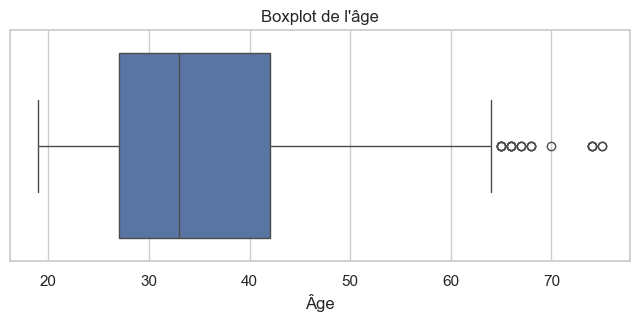

In [38]:
# Boxplot de l'âge
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x="age")
plt.title("Boxplot de l'âge")
plt.xlabel("Âge")
plt.show()

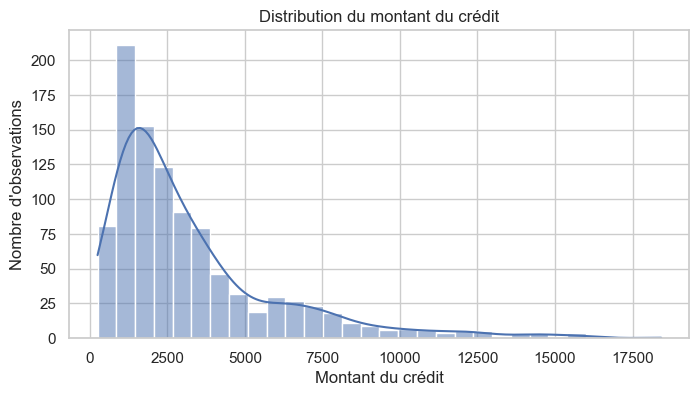

In [39]:
# Distribution du montant du crédit
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="credit_amount", bins=30, kde=True)
plt.title("Distribution du montant du crédit")
plt.xlabel("Montant du crédit")
plt.ylabel("Nombre d'observations")
plt.show()

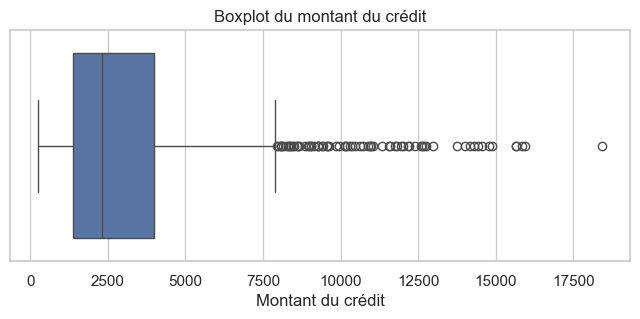

In [40]:
# Boxplot du montant du crédit
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x="credit_amount")
plt.title("Boxplot du montant du crédit")
plt.xlabel("Montant du crédit")
plt.show()

In [ ]:
# Crosstab sensible : credit_risk × personal_status_sex
pd.crosstab(
    df["personal_status_sex"],
    df["credit_risk"]
)

credit_risk,bad_credit,good_credit
personal_status_sex,,
female divorced/separated/married,109,201
male divorced/separated,20,30
male married/widowed,25,67
male single,146,402


In [42]:
# Crosstab sensible : credit_risk × personal_status_sex
crosstab = pd.crosstab(
    df["personal_status_sex"],
    df["credit_risk"],
    normalize="index"
) * 100

display(crosstab.round(2))



credit_risk,bad_credit,good_credit
personal_status_sex,,
female divorced/separated/married,35.160,64.840
male divorced/separated,40.000,60.000
male married/widowed,27.170,72.830
male single,26.640,73.360


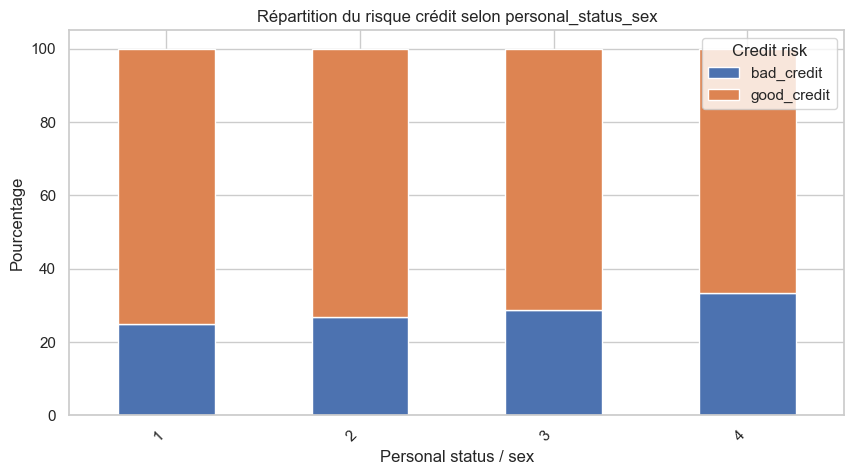

In [104]:
# Display stacked bar chart for credit risk distribution by personal_status
crosstab.plot(kind="bar", stacked=True, figsize=(10, 5))

plt.title("Répartition du risque crédit selon personal_status_sex")
plt.xlabel("Personal status / sex")
plt.ylabel("Pourcentage")
plt.legend(title="Credit risk")
plt.xticks(rotation=45, ha="right")
plt.show()


In [105]:
# Analyse du risque crédit par rapport au montant du crédit
crosstab = pd.crosstab(
    df["credit_amount"],
    df["credit_risk"],
    normalize="index"
) * 100

In [106]:
df.groupby("credit_risk")["credit_amount"].describe()

,count,mean,std,min,25%,50%,75%,max
credit_risk,,,,,,,,
bad_credit,300.000,3938.127,3535.819,433.000,1352.500,2574.500,5141.500,18424.000
good_credit,700.000,2985.457,2401.472,250.000,1375.500,2244.000,3634.750,15857.000


In [107]:
df.groupby("credit_risk")["credit_amount"].median()

credit_risk
bad_credit    2574.500
good_credit   2244.000
Name: credit_amount, dtype: float64

In [108]:
df.groupby("credit_risk")["credit_amount"].agg(["min", "median", "mean", "max", "std"])

,min,median,mean,max,std
credit_risk,,,,,
bad_credit,433,2574.500,3938.127,18424,3535.819
good_credit,250,2244.000,2985.457,15857,2401.472


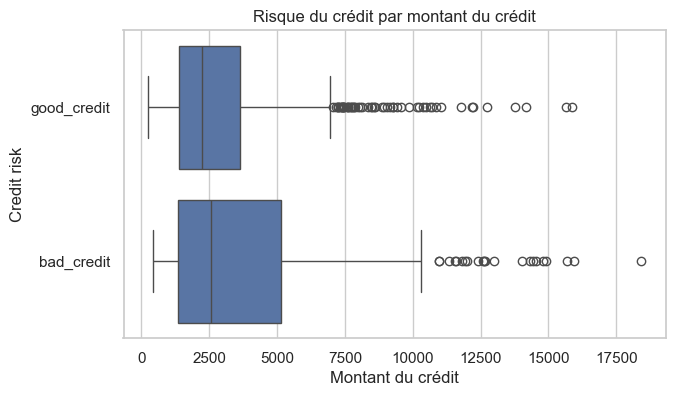

In [ ]:
# Boxplot du montant du crédit selon le risque crédit
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="credit_amount", y="credit_risk")
plt.title("Risque du crédit par montant du crédit")
plt.xlabel("Montant du crédit")
plt.ylabel("Credit risk")
plt.show()

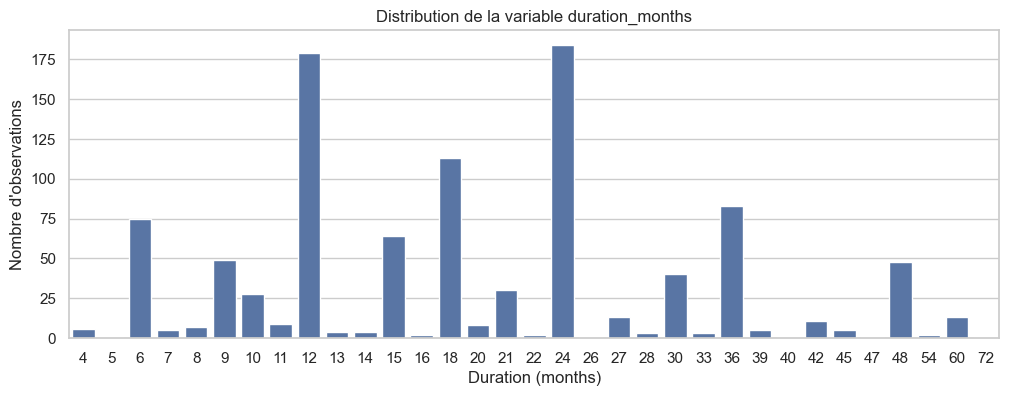

In [57]:
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x="duration_months")
plt.title("Distribution de la variable duration_months")
plt.xlabel("Duration (months)")
plt.ylabel("Nombre d'observations")
plt.show()

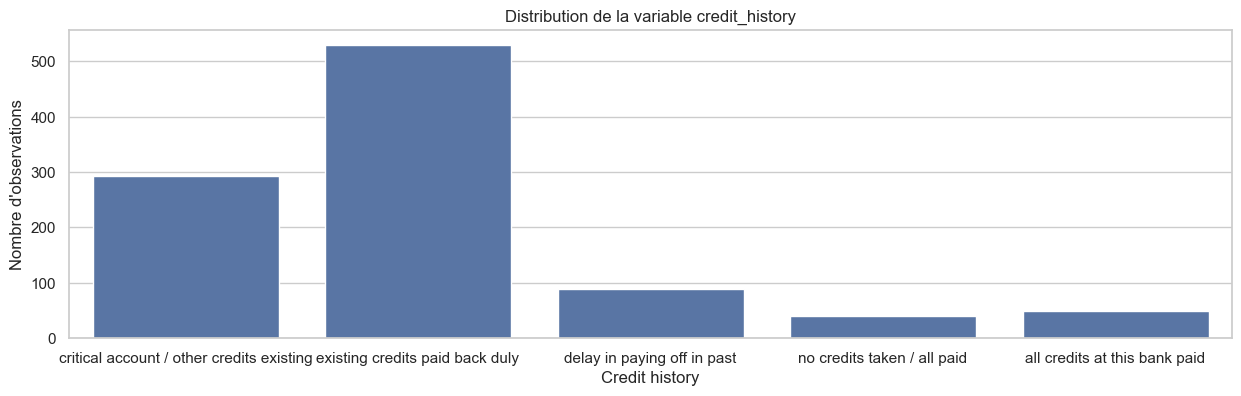

In [59]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df, x="credit_history")
plt.title("Distribution de la variable credit_history")
plt.xlabel("Credit history")
plt.ylabel("Nombre d'observations")
plt.show()

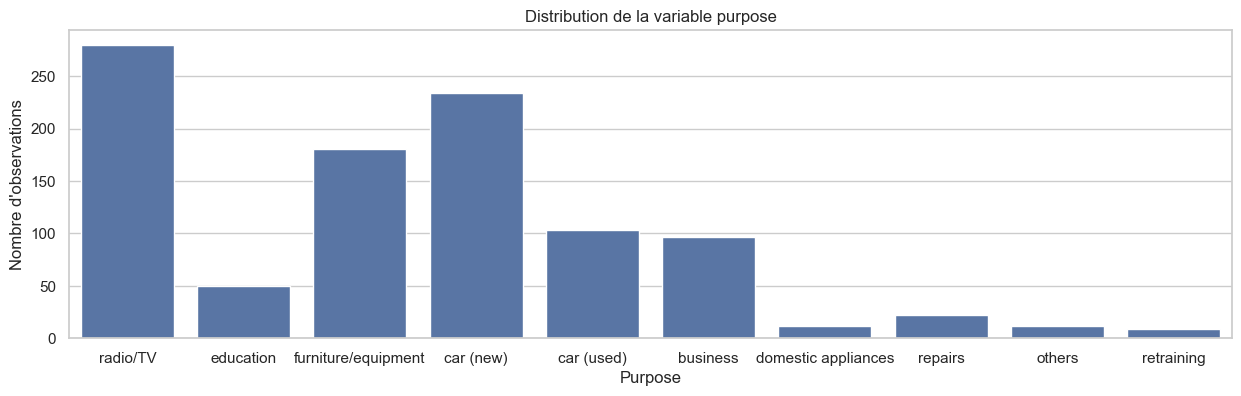

In [63]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df, x="purpose")
plt.title("Distribution de la variable purpose")
plt.xlabel("Purpose")
plt.ylabel("Nombre d'observations")
plt.show()

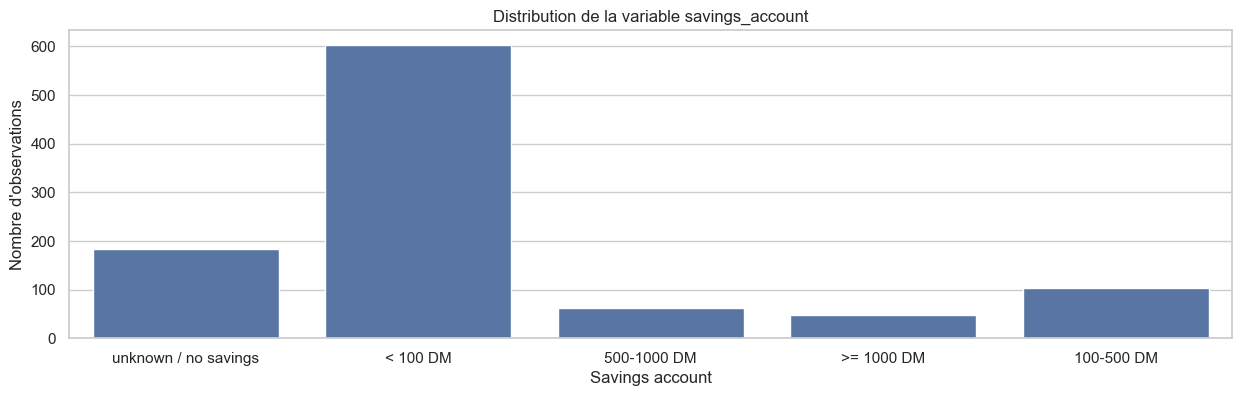

In [64]:
plt.figure(figsize=(15, 4))
sns.countplot(data=df, x="savings_account")
plt.title("Distribution de la variable savings_account")
plt.xlabel("Savings account")
plt.ylabel("Nombre d'observations")
plt.show()

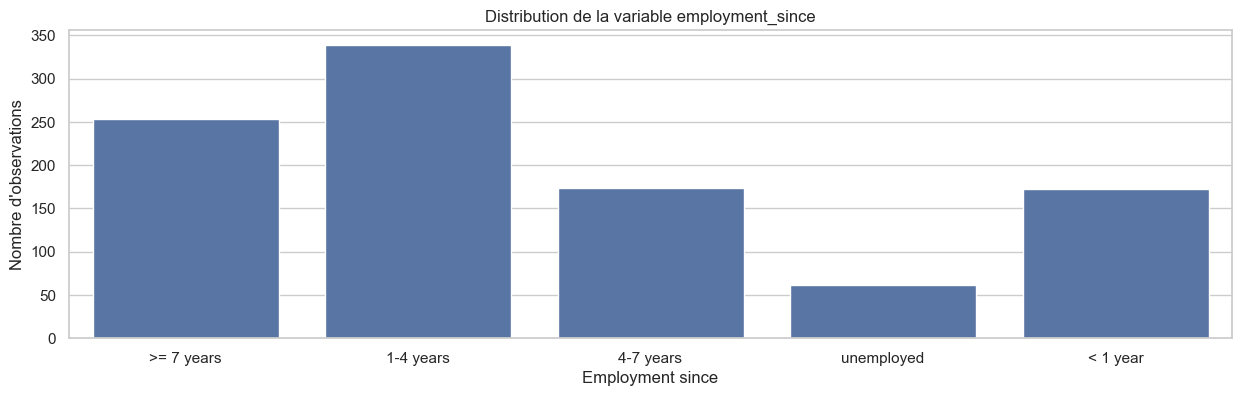

In [65]:

plt.figure(figsize=(15, 4))
sns.countplot(data=df, x="employment_since")
plt.title("Distribution de la variable employment_since")
plt.xlabel("Employment since")
plt.ylabel("Nombre d'observations")
plt.show()

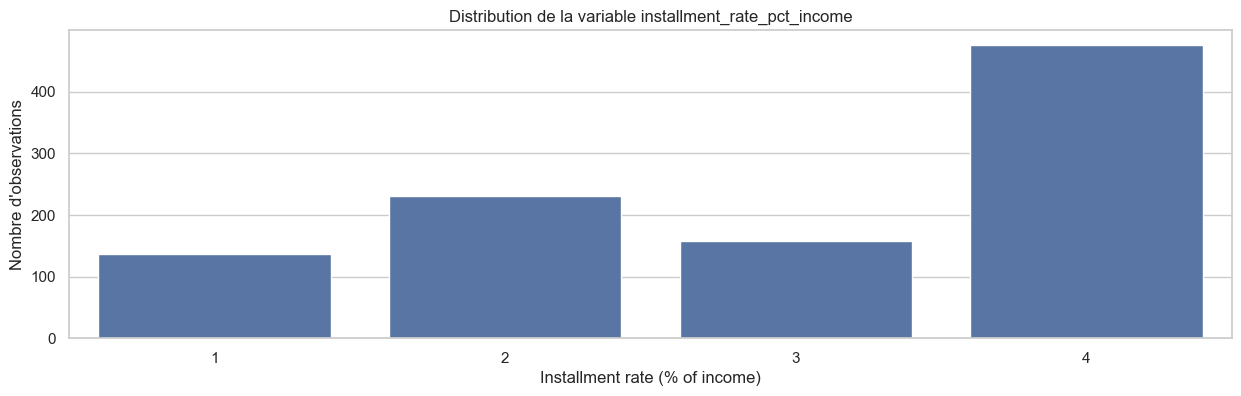

In [68]:
# pourcentage du revenu utilisé pour payer les mensualités
plt.figure(figsize=(15, 4))
sns.countplot(data=df, x="installment_rate_pct_income")
plt.title("Distribution de la variable installment_rate_pct_income")
plt.xlabel("Installment rate (% of income)")
plt.ylabel("Nombre d'observations")
plt.show()

In [73]:
crosstab = pd.crosstab(
    df["installment_rate_pct_income"],
    df["credit_risk"],
    normalize="index"
) * 100

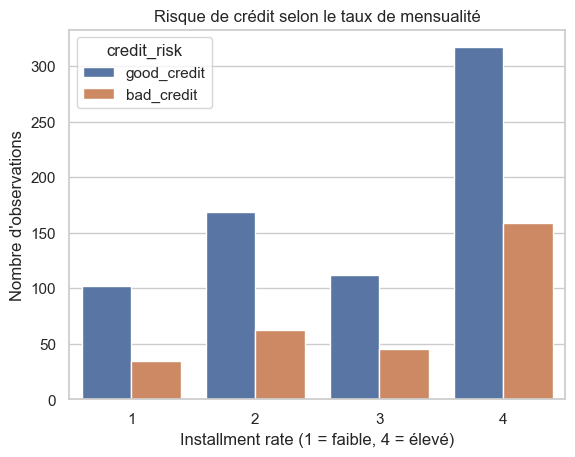

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df,
            x="installment_rate_pct_income",
            hue="credit_risk")

plt.title("Risque de crédit selon le taux de mensualité")
plt.xlabel("Installment rate (1 = faible, 4 = élevé)")
plt.ylabel("Nombre d'observations")
plt.show()

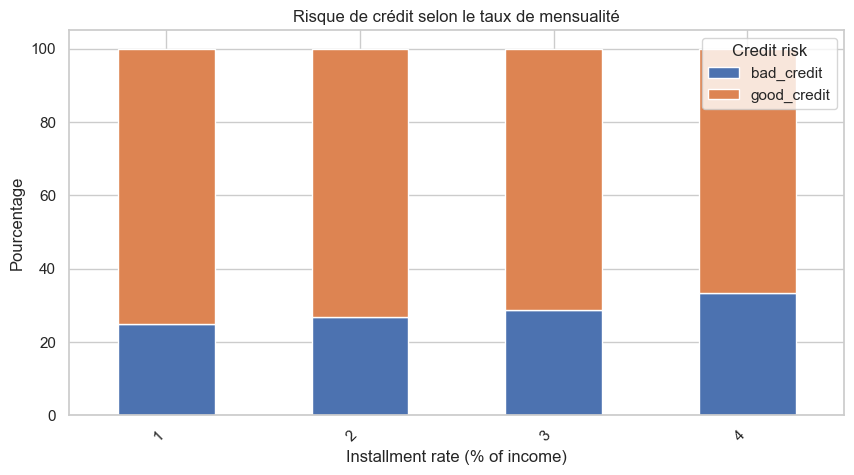

In [74]:
crosstab.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Risque de crédit selon le taux de mensualité")
plt.xlabel("Installment rate (% of income)")
plt.ylabel("Pourcentage")
plt.legend(title="Credit risk")
plt.xticks(rotation=45, ha="right")
plt.show()

## 3. Audit éthique léger (~1 h)

Déséquilibre cible + **disparate impact** sur au moins 2 variables sensibles.
Règle des 4/5 : `DI < 0.8` ou `> 1.25` → signal.

> *Quels biais structurels ai-je détectés ?* — court paragraphe.

⚠️ Pas de mitigation à ce stade — on documente, on alerte. La mitigation,
c'est M7.

In [109]:
def disparate_impact_table(df, sensitive_col, target_col="credit_risk", positive_label="good_credit"):
    # Effectifs par groupe
    counts = df.groupby(sensitive_col)[target_col].count()

    # Taux d'issue favorable par groupe
    positive_rate = df.groupby(sensitive_col)[target_col].apply(
        lambda x: (x == positive_label).mean()
    )

    # Groupe de référence = groupe avec le meilleur taux favorable
    reference_rate = positive_rate.max()

    # Disparate impact
    di = positive_rate / reference_rate

    result = pd.DataFrame({"count": counts,
                           "positive_rate": positive_rate,
                           "disparate_impact": di})

    result["positive_rate"] = (result["positive_rate"] * 100).round(2)
    result["disparate_impact"] = result["disparate_impact"].round(3)

    result["signal_4_5_rule"] = result["disparate_impact"].apply(
        lambda x: "Signal" if (x < 0.8 or x > 1.25) else "OK"
    )

    return result.sort_values("disparate_impact")

In [78]:
# TODO — Disparate impact sur foreign_worker (par exemple) :
# DI = P(good_credit | foreign_worker=non) / P(good_credit | foreign_worker=oui)
di_foreign_worker = disparate_impact_table(
    df,
    sensitive_col="foreign_worker",
    target_col="credit_risk",
    positive_label="good_credit"
)

display(di_foreign_worker)

,count,positive_rate,disparate_impact,signal_4_5_rule
foreign_worker,,,,
yes,963,69.260,0.777,Signal
no,37,89.190,1.000,OK


In [79]:
# TODO — Disparate impact sur personal_status_sex
# Note : variable composite — fais un constat même si l'interprétation est limitée
di_personal_status = disparate_impact_table(
    df,
    sensitive_col="personal_status_sex",
    target_col="credit_risk",
    positive_label="good_credit"
)

display(di_personal_status)

,count,positive_rate,disparate_impact,signal_4_5_rule
personal_status_sex,,,,
male divorced/separated,50,60.000,0.818,OK
female divorced/separated/married,310,64.840,0.884,OK
male married/widowed,92,72.830,0.993,OK
male single,548,73.360,1.000,OK


In [82]:

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 100],
    labels=["<=25", "26-35", "36-50", ">50"]
)

di_age = disparate_impact_table(
    df,
    sensitive_col="age_group",
    target_col="credit_risk",
    positive_label="good_credit"
)

display(di_age)

C:\Users\hsuty\AppData\Local\Temp\ipykernel_3784\2567581239.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(sensitive_col)[target_col].count()
C:\Users\hsuty\AppData\Local\Temp\ipykernel_3784\2567581239.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  positive_rate = df.groupby(sensitive_col)[target_col].apply(


,count,positive_rate,disparate_impact,signal_4_5_rule
age_group,,,,
<=25,190,57.890,0.759,Signal
26-35,398,70.350,0.923,OK
>50,113,72.570,0.952,OK
36-50,299,76.250,1.000,OK


## 4. Choix de prétraitement (~30 min)

Pour chaque feature, décide : numérique (impute + scale), ordinale
(impute + ordinal encoding **avec ordre**), catégorielle (impute + onehot),
ou exclue (justifie).

Remplis les listes `NUMERIC_FEATURES`, `ORDINAL_FEATURES`,
`CATEGORICAL_FEATURES` dans `src/preprocess.py`.

In [ ]:
# Catégoriel nominal
# purpose
# other_installment_plans
# housing
# telephone
# other_debtors
# job
# "credit_history" - Ordre métier impossible à définir:
#   "critical account / other credits existing"
#   "existing credits paid back duly"
#   "delay in paying off in past"
#   "no credits taken / all paid" ==> all paid et n'a jamais pris de crédit ne peut être considéré dans la même catégorie ordonnée
#   "all credits at this bank paid"

In [ ]:
# Catégorie encodée de manière ordinale (ordre métier naturel) :
# --------------------------------------------------------------

# catégorie "checking_account_status" - Ordre métier naturel :
# < 0 DM                                  → 0
# 0 ≤ x < 200 DM                          → 1
# 200 ≤ x < 500 DM                        → 2
# ≥ 500 DM                                → 3

# catégorie "savings_account" - Ordre métier naturel :
# unknown                                  → 0
# < 100 DM                                 → 1
# 100 ≤ x < 500 DM                         → 2
# 500 ≤ x < 1000 DM                        → 3
# ≥ 1000 DM or                             → 4

# catégorie "employment_since" - Ordre métier naturel :
# unemployed                                → 0
# less than 1 year                          → 1
# 1 to 4 years                              → 2
# 4 to 7 years                              → 3
# more than 7 years                         → 4

# Catégorie "property" - Ordre métier naturel :
# unknown / no property                  → 0
# car or other                           → 1
# savings agreement / life insurance     → 2
# real estate                            → 3

In [ ]:
# Numérique
# numeric_features = ["duration_months", "credit_amount", "installment_rate_pct_income", "residence_since_years", "age", "n_existing_credits", "n_people_liable"]

In [ ]:
# Abandonné
# abandonned_features = ["personal_status_sex", "foreign_worker"]

## 5. Industrialisation Pipeline (~1 h 15)

Une fois `src/preprocess.py` complété, fitte le pipeline et sauve-le.

### 🎓 Pourquoi un `Pipeline` ? (définition — la fuite de données)

Tu pourrais imputer/encoder/scaler « à la main » en Pandas. On enferme tout
dans un `Pipeline` parce qu'un préprocesseur **apprend des paramètres sur les
données** : `SimpleImputer` retient une médiane, `StandardScaler` une moyenne
et un écart-type, `OneHotEncoder` la liste des modalités.

**Fuite de données** (*data leakage*) = laisser de l'information du jeu de
**test** influencer la préparation du jeu d'**entraînement** — typiquement
calculer ces paramètres sur *tout* le dataset avant de le splitter. Symptôme :
des scores de validation **anormalement optimistes** qui s'effondrent en prod.

Le `Pipeline` est l'outil qui rend l'étanchéité automatique : un seul `fit` sur
le train propage la discipline à toutes les transformations. **Ici tu n'as pas
de split** (on produit juste un dataset propre) → `fit_transform` sur tout le
dataset est OK. **Réflexe à garder** : *dès qu'un modèle entre en jeu, le
préprocesseur ne se `fit` que sur le train.* → mise en œuvre en **M4-B1**.

In [25]:
import sys
sys.path.append("../src")
from preprocess import build_preprocessor, load_dataset

X, y = load_dataset(RAW_PATH)
preprocessor = build_preprocessor()
X_transformed = preprocessor.fit_transform(X)

print(f"Shape originale : {X.shape}")
print(f"Shape transformée : {X_transformed.shape}")

print(preprocessor)

Shape originale : (1000, 18)
Shape transformée : (1000, 41)
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['duration_months', 'credit_amount',
                                  'installment_rate_pct_income',
                                  'residence_since_years', 'age',
                                  'n_existing_credits', 'n_people_liable']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal...
                                 ['checking_account_status', 'savings_account',
                                  'employment_since', 'prope

In [26]:
for name, transformer, columns in preprocessor.transformers:
    print(f"\n{name}")
    print(columns)


num
['duration_months', 'credit_amount', 'installment_rate_pct_income', 'residence_since_years', 'age', 'n_existing_credits', 'n_people_liable']

ord
['checking_account_status', 'savings_account', 'employment_since', 'property']

cat
['purpose', 'other_installment_plans', 'housing', 'telephone', 'other_debtors', 'job', 'credit_history']


In [27]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names)
print(len(feature_names))

['duration_months' 'credit_amount' 'installment_rate_pct_income'
 'residence_since_years' 'age' 'n_existing_credits' 'n_people_liable'
 'checking_account_status' 'savings_account' 'employment_since' 'property'
 'purpose_business' 'purpose_car (new)' 'purpose_car (used)'
 'purpose_domestic appliances' 'purpose_education'
 'purpose_furniture/equipment' 'purpose_others' 'purpose_radio/TV'
 'purpose_repairs' 'purpose_retraining' 'other_installment_plans_bank'
 'other_installment_plans_none' 'other_installment_plans_stores'
 'housing_for free' 'housing_own' 'housing_rent' 'telephone_none'
 'telephone_yes, registered' 'other_debtors_co-applicant'
 'other_debtors_guarantor' 'other_debtors_none'
 'job_management / self-employed / highly qualified'
 'job_skilled employee / official'
 'job_unemployed / unskilled non-resident' 'job_unskilled resident'
 'credit_history_all credits at this bank paid'
 'credit_history_critical account / other credits existing'
 'credit_history_delay in paying off in

In [28]:
comparison = pd.DataFrame({
    "original": X["checking_account_status"],
    "encoded": X_transformed_df["property"]
})

display(comparison.head(10))

,original,encoded
0,< 0 DM,3.000
1,0 to 200 DM,3.000
2,no checking account,3.000
3,< 0 DM,2.000
4,< 0 DM,0.000
5,no checking account,0.000
6,no checking account,2.000
7,0 to 200 DM,1.000
8,no checking account,3.000
9,0 to 200 DM,1.000


In [29]:
comparison = pd.DataFrame({
    "original": X["savings_account"],
    "encoded": X_transformed_df["savings_account"]
})

display(comparison.head(10))

,original,encoded
0,unknown / no savings,0.000
1,< 100 DM,1.000
2,< 100 DM,1.000
3,< 100 DM,1.000
4,< 100 DM,1.000
5,unknown / no savings,0.000
6,500-1000 DM,3.000
7,< 100 DM,1.000
8,>= 1000 DM,-1.000
9,< 100 DM,1.000


In [30]:
comparison = pd.DataFrame({
    "original": X["employment_since"],
    "encoded": X_transformed_df["employment_since"]
})

display(comparison.head(10))

,original,encoded
0,>= 7 years,-1.000
1,1-4 years,2.000
2,4-7 years,3.000
3,4-7 years,3.000
4,1-4 years,2.000
5,1-4 years,2.000
6,>= 7 years,-1.000
7,1-4 years,2.000
8,4-7 years,3.000
9,unemployed,0.000


In [16]:
comparison = pd.DataFrame({
    "original": X["property"],
    "encoded": X_transformed_df["checking_account_status"]
})

display(comparison.head(10))

,original,encoded
0,real estate,1.000
1,real estate,2.000
2,real estate,0.000
3,savings agreement / life insurance,1.000
4,unknown / no property,1.000
5,unknown / no property,0.000
6,savings agreement / life insurance,0.000
7,car or other,2.000
8,real estate,0.000
9,car or other,2.000


In [4]:
import joblib
joblib.dump(preprocessor, "../src/pipeline.joblib", compress=3)

['../src/pipeline.joblib']

In [ ]:

purpose_cols = [
    col for col in X_transformed_df.columns
    if col.startswith("purpose_")
]

display(X_transformed_df[purpose_cols].head())


In [12]:
display(X_transformed_df.isna().sum().sum())

0

## 6. Persistance Parquet + datasheet (~45 min)

Sauve le dataset propre en Parquet (pyarrow) et complète `datasheet.md`
(7 sections Gebru, schéma documenté dans *Composition*).

In [ ]:
# TODO — sauve un DataFrame *propre* (post-imputation si tu veux) en Parquet :
# df_clean.to_parquet(CLEAN_PATH, engine="pyarrow", compression="snappy")

In [ ]:
# Vérification relecture
df_back = pd.read_parquet(CLEAN_PATH)
print(f"Relu : {df_back.shape}, types préservés : {df_back.dtypes.value_counts().to_dict()}")

csv_size = RAW_PATH.stat().st_size / 1024
pq_size = CLEAN_PATH.stat().st_size / 1024
print(f"CSV : {csv_size:.1f} Ko · Parquet : {pq_size:.1f} Ko (compression : {csv_size/pq_size:.1f}x)")

## 7. Synthèse audit.md (~30 min)

Complète `audit.md` : verdict qualité (3-5 problèmes) + verdict éthique
(2-3 alertes) + recommandations. Lisible par le DPO Klaus Eichmann
(pas de jargon scikit-learn).